### Problem 1: Backpropagation by Hand

Given
$$
X = [1.0,\;0.5],
\qquad
W_1 =
\begin{pmatrix}
0.5 & -0.3\\
0.2 & 0.8
\end{pmatrix},
\qquad
b_1 = [0.1,\;-0.1]
$$
$$
w_2 =
\begin{pmatrix}
0.6\\
-0.4
\end{pmatrix},
\qquad
b_2 = 0.2
$$

####  (a). Forward Pass

Solving for $z_1$:

$$
z_1 = X W_1^T + b_1
$$,

where

$$
W_1^T =
\begin{pmatrix}
0.5 & 0.2\\
-0.3 & 0.8
\end{pmatrix}
$$

$$
XW_1^T
=
[1.0,\;0.5]
\begin{pmatrix}
0.5 & 0.2\\
-0.3 & 0.8
\end{pmatrix}
$$
$$
=
\left[
(1.0)(0.5) + (0.5)(-0.3),\;
(1.0)(0.2) + (0.5)(0.8)
\right]
$$

$$
=
[0.5 - 0.15,\;0.2 + 0.4]
$$
$$
=
[0.35,\;0.6]
$$

Adding the bias $b_1$:
$$
z_1 = [0.35,\;0.6] + [0.1,\;-0.1] = [0.45,\;0.50]
$$

-----------------------------------------------

Now apply the sigmoid activation:

$$
h = \sigma(z_i) = \frac{1}{1+e^{-z_i}}
$$

$$
h = [\sigma(0.45),\;\sigma(0.5)]
$$

$$
h \approx [0.611,\;0.622]
$$
-----------------------------------------------


Solving for $z_2$:
$$
z_2 = h w_2 + b_2
$$

$$
z_2 =
[0.611,\;0.622]
\begin{pmatrix}
0.6\\
-0.4
\end{pmatrix}
+ 0.2
$$

$$
= (0.611)(0.6) + (0.622)(-0.4) + 0.2
$$

$$
= 0.3666 - 0.2488 + 0.2
$$

$$
\approx 0.3178
$$

-----------------------------------------------

Apply the sigmoid activation to get $\hat{y}$:

$$
\hat{y} = \sigma(z_2) = \sigma(0.3178)
$$

$$
\hat{y} \approx 0.579
$$

Thus,
$$
\boxed{
z_1^{(1)} = 0.45, \qquad
z_2^{(1)} = 0.50, \qquad
h_1 = 0.611, \qquad
h_2 = 0.622, \qquad
z^{(2)} = 0.318, \qquad
\hat{y} = 0.579
}
$$

#### (b). Loss

For a single training example, the binary cross-entropy loss is
$$
L = -\left[y\ln(\hat{y}) + (1-y)\ln(1-\hat{y})\right]
$$

The true label is $y=1$, so this becomes
$$
L = -\left[1\cdot \ln(\hat{y}) + 0\cdot \ln(1-\hat{y})\right]
$$

$$
L = -\ln(\hat{y})
$$

From part (a), $\hat{y} = 0.579$:

$$
L = -\ln(0.579)
$$

$$
\boxed{L \approx 0.546}
$$

#### (c). Backward Pass

$$
\delta^{(2)} = \hat{y} - y
$$

$$
= 0.579 - 1
$$

$$
= -0.421
$$

-----------------------------------------------

Next, the gradient with respect to $w_2$ is

$$
\frac{\partial L}{\partial w_2} = h^T \delta^{(2)}
$$

$$
=
\begin{pmatrix}
0.611\\
0.622
\end{pmatrix}
(-0.421)
$$
$$
=
\begin{pmatrix}
-0.257\\
-0.262
\end{pmatrix}
$$

-----------------------------------------------

Since we only have one training example, the gradient with respect to $b_2$ is
$$
\frac{\partial L}{\partial b_2} = \delta^{(2)}
$$
$$
= -0.421
$$

-----------------------------------------------

Now solving for $\delta^{(1)}$:

$$
\delta^{(1)} = (\delta_2 W_2^T) \odot h \odot (1 - h)
$$

$$
(-0.421)[0.6,\;-0.4] \odot [0.611(1-0.611),\;0.622(1-0.622)]
$$

$$
= [-0.2526,\;0.1684] \odot [0.611(0.389),\;0.622(0.378)]
$$

$$
= [-0.2526,\;0.1684] \odot [0.2377,\;0.2351]
$$


$$
\approx [-0.060,\;0.040]
$$

-----------------------------------------------

The gradient with respect to $W_1$ is
$$
\frac{\partial L}{\partial W^{(1)}} = \frac{\delta_1^T X}{N}
$$

There is only one training example, so

$$
\frac{\partial L}{\partial W^{(1)}} = \delta_1^T X
$$

$$
=
\begin{pmatrix}
-0.060\\
0.040
\end{pmatrix}
[1.0,\;0.5]
$$

$$
=
\begin{pmatrix}
-0.060(1.0) & -0.060(0.5)\\
0.040(1.0) & 0.040(0.5)
\end{pmatrix}
$$

$$
=
\begin{pmatrix}
-0.060 & -0.030\\
0.040 & 0.020
\end{pmatrix}
$$

-----------------------------------------------

The gradient with respect to $b_1$ is
$$
\frac{\partial L}{\partial b_1} = \delta^{(1)}
\approx [-0.060,\;0.040]
$$

Therefore,
$$
\boxed{
\begin{aligned}
\delta^{(2)} &\approx -0.421 \\
\frac{\partial L}{\partial w_2} &\approx
\begin{pmatrix}
-0.257\\
-0.262
\end{pmatrix} \\
\frac{\partial L}{\partial b_2} &\approx -0.421 \\
\delta^{(1)} &\approx [-0.060,\;0.040] \\
\frac{\partial L}{\partial W_1} &\approx
\begin{pmatrix}
-0.060 & -0.030\\
0.040 & 0.020
\end{pmatrix} \\
\frac{\partial L}{\partial b_1} &\approx [-0.060,\;0.040]
\end{aligned}
}
$$

#### (d). Update

Using gradient descent,
$$
w^{(2)}_{\text{new}} = w^{(2)} - \eta \frac{\partial L}{\partial w^{(2)}}
$$

$$
b^{(2)}_{\text{new}} = b^{(2)} - \eta \frac{\partial L}{\partial b^{(2)}}
$$

where
$$
\eta = 0.1
$$

we get
$$
w^{(2)}_{\text{new}}
=
\begin{pmatrix}
0.6\\
-0.4
\end{pmatrix}
-
0.1
\begin{pmatrix}
-0.257\\
-0.262
\end{pmatrix}
$$

$$
=
\begin{pmatrix}
0.6\\
-0.4
\end{pmatrix}
-
\begin{pmatrix}
-0.0257\\
-0.0262
\end{pmatrix}
$$

$$
=
\begin{pmatrix}
0.6257\\
-0.3738
\end{pmatrix}
$$

and 
$$
b^{(2)}_{\text{new}} = 0.2 - 0.1(-0.421)
$$

$$
= 0.2421
$$

Therefore,
$$
\boxed{
w^{(2)}_{\text{new}} \approx
\begin{pmatrix}
0.6257\\
-0.3738
\end{pmatrix},
\qquad
b^{(2)}_{\text{new}} \approx 0.2421
}
$$

#### (e). Interpretation.

Backpropagation is called "backpropagation" because it involves propagating the error signal backward through the network.

Input data is fed through the neural network layer by layer to generate an output prediction. Each neuron computes a weighted sum of its inputs and applies an activation function to introduce non-linearity. The prediction is then compared to the actual output using a loss function, which produces a single scalar value that quantifies the error. Starting from the output layer, the algorithm propagates this error signal backward through the network. By applying the chain rule, it determines how much each weight and bias contributed to the total error so the parameters can be updated to reduce the loss.

### Problem 2: Extending the From-Scratch Network


####  (a). New activation function.


In [2]:
# Modify the forward and backward functions to use tanh in the hidden layer 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})
    
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = np.tanh(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

In [4]:
def binary_cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [5]:
def backward(X, y, y_hat, h, W2):
    """Backpropagation for a 2-layer network."""
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * (1 - h**2)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

In [6]:
def train_network(X, y, H=4, lr=0.5, n_epochs=2000, verbose=True, ndiv=500):
    N, D = X.shape
    rng = np.random.default_rng(0)
    W1 = rng.standard_normal((H, D)) * 0.5
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * 0.5
    b2 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h = forward(X, W1, b1, W2, b2)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g = backward(X, y, y_hat, h, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f'  epoch {epoch:5d}  loss = {loss:.4f}  acc = {acc:.2%}')
    return W1, b1, W2, b2, losses

In [7]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

print('Training on XOR problem...')
W1_xor, b1_xor, W2_xor, b2_xor, losses_xor = train_network(
    X_xor, y_xor, H=4, lr=2.0, n_epochs=5000
)

y_pred_xor, _ = forward(X_xor, W1_xor, b1_xor, W2_xor, b2_xor)
print(f'\nFinal predictions: {y_pred_xor.round(3)}')
print(f'True labels:       {y_xor}')

Training on XOR problem...
  epoch     0  loss = 0.6948  acc = 50.00%
  epoch   500  loss = 0.0014  acc = 100.00%
  epoch  1000  loss = 0.0006  acc = 100.00%
  epoch  1500  loss = 0.0004  acc = 100.00%
  epoch  2000  loss = 0.0003  acc = 100.00%
  epoch  2500  loss = 0.0002  acc = 100.00%
  epoch  3000  loss = 0.0002  acc = 100.00%
  epoch  3500  loss = 0.0002  acc = 100.00%
  epoch  4000  loss = 0.0001  acc = 100.00%
  epoch  4500  loss = 0.0001  acc = 100.00%

Final predictions: [0. 1. 1. 0.]
True labels:       [0. 1. 1. 0.]


I tested the modified network on the XOR dataset and the network still converged and correctly classified all four XOR inputs, confirming that the implementation works.

#### (b). Two moons dataset

In [13]:
# Applying the tanh network to the two moons dataset
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Training with H = 10 hidden neurons 
W1, b1, W2, b2, losses = train_network(
    X_train, y_train.astype(float), H=10, lr=0.1, n_epochs=25000, ndiv=5000
)

y_hat, _ = forward(X_test, W1, b1, W2, b2)
y_pred_nn = (y_hat > 0.5).astype(int)
acc_nn = accuracy_score(y_test, y_pred_nn)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f'\nLogistic regression accuracy: {acc_lr:.2%}')
print(f'Neural network accuracy:      {acc_nn:.2%}')

  epoch     0  loss = 0.5913  acc = 68.50%
  epoch  5000  loss = 0.0968  acc = 97.12%
  epoch 10000  loss = 0.0842  acc = 97.12%
  epoch 15000  loss = 0.0799  acc = 97.12%
  epoch 20000  loss = 0.0769  acc = 97.25%

Logistic regression accuracy: 91.00%
Neural network accuracy:      98.50%


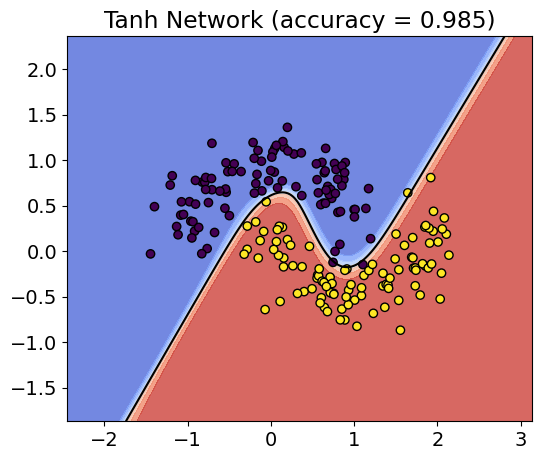

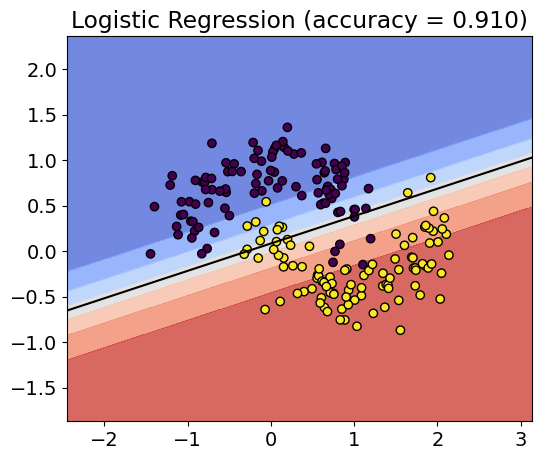

In [16]:
def plot_boundary(model_func, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_func(grid).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.8)
    plt.contour(xx, yy, Z, levels=[0.5], colors='k')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', edgecolors='k')
    plt.title(title)
    plt.show()

plot_boundary(
    lambda grid: forward(grid, W1, b1, W2, b2)[0],
    X_test, y_test,
    f"Tanh Network (accuracy = {acc_nn:.3f})"
)

plot_boundary(
    lambda grid: logreg.predict_proba(grid)[:,1],
    X_test, y_test,
    f"Logistic Regression (accuracy = {acc_lr:.3f})"
)

The tanh neural network (accuracy 0.985) achieves higher accuracy than logistic regression (accuracy 0.910) because it can learn a nonlinear decision boundary, while logistic regression is limited to a linear separator.

#### (c). Adding a second hidden layer

In [10]:
def forward_2layer(X, W1, b1, W2, b2, W3, b3):
    z1 = X @ W1.T + b1
    h1 = np.tanh(z1)

    z2 = h1 @ W2.T + b2
    h2 = np.tanh(z2)

    z3 = h2 @ W3 + b3
    y_hat = sigmoid(z3)

    return y_hat, h1, h2


def backward_2layer(X, y, y_hat, h1, h2, W2, W3):
    N = len(y)

    delta3 = y_hat - y
    dW3 = (h2.T @ delta3) / N
    db3 = np.mean(delta3)

    delta2 = np.outer(delta3, W3) * (1 - h2**2)
    dW2 = (delta2.T @ h1) / N
    db2 = np.mean(delta2, axis=0)

    delta1 = (delta2 @ W2) * (1 - h1**2)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)

    return dW1, db1, dW2, db2, dW3, db3


def train_network_2layer(X, y, H1=10, H2=5, lr=0.1, n_epochs=25000, verbose=True, ndiv=5000):
    N, D = X.shape
    rng = np.random.default_rng(0)

    W1 = rng.standard_normal((H1, D)) * 0.5
    b1 = np.zeros(H1)

    W2 = rng.standard_normal((H2, H1)) * 0.5
    b2 = np.zeros(H2)

    W3 = rng.standard_normal(H2) * 0.5
    b3 = 0.0

    losses = []

    for epoch in range(n_epochs):
        y_hat, h1, h2 = forward_2layer(X, W1, b1, W2, b2, W3, b3)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)

        dW1, db1_g, dW2, db2_g, dW3, db3_g = backward_2layer(
            X, y, y_hat, h1, h2, W2, W3
        )

        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        W3 -= lr * dW3
        b3 -= lr * db3_g

        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f'  epoch {epoch:5d}  loss = {loss:.4f}  acc = {acc:.2%}')

    return W1, b1, W2, b2, W3, b3, losses

In [21]:
W1, b1, W2, b2, W3, b3, losses = train_network_2layer(
    X_train, y_train.astype(float), H1=10, H2=5, lr=0.1, n_epochs=25000, ndiv=5000
)

y_hat, _, _ = forward_2layer(X_test, W1, b1, W2, b2, W3, b3)
y_pred_nn_2layer = (y_hat > 0.5).astype(int)
acc_nn_2layer = accuracy_score(y_test, y_pred_nn_2layer)

print(f'Two-hidden-layer neural network accuracy: {acc_nn_2layer:.2%}')
print(f'Single-hidden-layer neural network accuracy: {0.985:.2%}')

  epoch     0  loss = 0.9470  acc = 33.50%
  epoch  5000  loss = 0.0676  acc = 97.75%
  epoch 10000  loss = 0.0613  acc = 97.75%
  epoch 15000  loss = 0.0582  acc = 98.00%
  epoch 20000  loss = 0.0564  acc = 97.75%
Two-hidden-layer neural network accuracy: 99.00%
Single-hidden-layer neural network accuracy: 98.50%


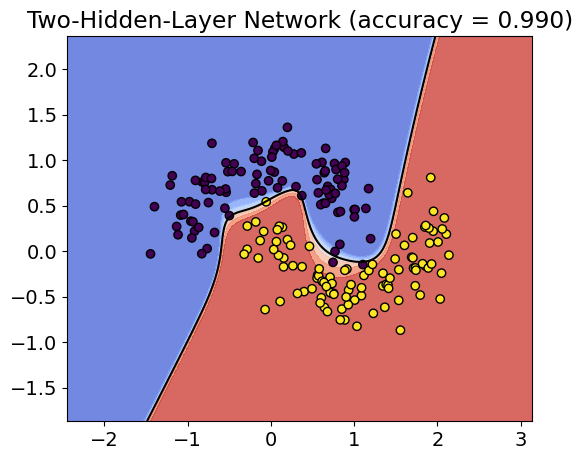

In [22]:
plot_boundary(
    lambda grid: forward_2layer(grid, W1, b1, W2, b2, W3, b3)[0],
    X_test, y_test,
    f"Two-Hidden-Layer Network (accuracy = {acc_nn_2layer:.3f})"
)

The second hidden layer gives a small improvement in test accuracy, from 98.5% to 99.0% on this split.

#### (d). Discussion

The hardest part of adding the second layer was extending the backpropagation. We had to make sure we were using the correct weight matrix when propagating errors backward and that we were applying the correct derivatives of the activation functions at each layer. The main errors that arose were when making sure the matrix dimensions matched throughout the network. It was also tricky to keep the variables organized so that the activations and gradients for the first and second hidden layers were not mixed up. As the network gets deeper, implementing these calculations gets increasingly complicated and error prone. Frameworks like PyTorch automatically handle these operations by using automatic differentiation. As the matrix gets deeper, PyTorch can automatically compute gradients and handle tensor operations, which is very helpful for reliably training large models. 
